# Detección de fraude — enfoque no supervisado (DBSCAN e Isolation Forest)

**Problema.** Detectar transacciones anómalas **sin utilizar la variable objetivo** para
entrenar, reservándola únicamente para evaluar los resultados a posteriori. Es el escenario
realista cuando no se dispone de casos de fraude etiquetados.

**Enfoque.** Dos familias de algoritmos —clustering basado en densidad (DBSCAN) y aislamiento
de observaciones (Isolation Forest)— con dos configuraciones cada una, y comparación
sistemática de precision, recall y F1.

**Stack.** Python · pandas · scikit-learn · matplotlib

---

> **Datos.** Este notebook utiliza el conjunto *Credit Card Fraud Detection* del grupo de
> Machine Learning de la Université Libre de Bruxelles, disponible públicamente en
> [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) bajo licencia
> Database Contents License v1.0. Contiene 284.807 transacciones de tarjetas europeas,
> de las cuales 492 son fraudulentas (0,172%). Las variables `V1`–`V28` son componentes
> principales obtenidas por PCA para preservar la confidencialidad; `Amount` y `Class`
> son las únicas no transformadas.
>
> El fichero no se incluye en el repositorio por tamaño: descárgalo de Kaggle y cárgalo
> cuando el notebook lo solicite.

In [ ]:
from google.colab import files

# Ejecutamos la subida del archivo
uploaded = files.upload()

Saving fraud_csv.csv to fraud_csv (1).csv


## Importar librerías necesarias

Librerías para manipulación de datos

In [ ]:
import pandas as pd
import numpy as np

# Librerías para gráficos
import matplotlib.pyplot as plt

# Librería para estandarizar los datos
from sklearn.preprocessing import StandardScaler

# Modelo DBSCAN
from sklearn.cluster import DBSCAN

# Modelo Isolation Forest
from sklearn.ensemble import IsolationForest

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## Carga del dataset

Leemos el archivo fraud_csv (1).csv y lo guardamos en un DataFrame llamado df Usamos sep=';' para indicar que las columnas están separadas por punto y coma Usamos header=2 para seleccionar la fila 'V1;V2;V3;...' como encabezado (tercera línea) Usamos encoding='utf-8-sig' para manejar el Byte Order Mark (BOM)

In [ ]:
df = pd.read_csv("fraud_csv (1).csv", sep=';', header=2, encoding='utf-8-sig')

# Mostramos las primeras filas del dataset
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
1,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
2,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
3,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
4,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


## Análisis exploratorio inicial

Comprobamos el tamaño del dataset: número de filas y columnas

In [ ]:
print("Tamaño del dataset:")
print(df.shape)

# Comprobamos los tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Comprobamos si existen valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Analizamos la distribución de la variable objetivo Class
print("\nDistribución de la variable Class:")
print(df["Class"].value_counts())

# Porcentaje de transacciones legítimas y fraudulentas
print("\nDistribución porcentual de Class:")
print(df["Class"].value_counts(normalize=True) * 100)

Tamaño del dataset:
(10492, 30)

Tipos de datos:
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valores nulos por columna:
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: in

## Resumen estadístico del dataset

Mostramos estadísticas descriptivas de todas las variables numéricas

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,10492.0,-0.253891,2.653492,-34.591213,-1.042351,-0.089763,1.293633,2.399241
V2,10492.0,0.139075,2.085015,-48.060856,-0.592149,0.097423,0.878073,22.057729
V3,10492.0,-0.316120,2.577539,-31.103685,-1.058140,0.109849,1.004156,3.971381
V4,10492.0,0.189900,1.784402,-5.519697,-0.828834,0.052344,0.864884,12.114672
V5,10492.0,-0.157146,1.932408,-32.092129,-0.775055,-0.090850,0.595840,31.457046
V6,10492.0,-0.089793,1.410982,-21.248752,-0.827758,-0.308099,0.367013,21.393069
V7,10492.0,-0.268097,2.283644,-43.557242,-0.636476,0.008830,0.544240,34.303177
V8,10492.0,0.031490,1.818611,-41.044261,-0.213772,0.025583,0.352854,20.007208
V9,10492.0,-0.109778,1.326424,-13.434066,-0.723760,-0.086079,0.584019,7.938980
V10,10492.0,-0.240233,1.922037,-24.588262,-0.608855,-0.114520,0.434866,11.519106


## Crear dataframe sin la variable target

Como DBSCAN e Isolation Forest son modelos no supervisados, no se usa la variable Class para entrenar los modelos. La variable Class se guarda solo para evaluar después los resultados.

In [ ]:
df_sin_target = df.drop("Class", axis=1)

# Convertimos el DataFrame sin target en una matriz numérica
matriz_df_sin_target = df_sin_target.values

# Comprobamos la forma de la matriz
print("Forma de la matriz sin target:")
print(matriz_df_sin_target.shape)

Forma de la matriz sin target:
(10492, 29)


## Estandarización de los datos

La estandarización es especialmente importante para DBSCAN, porque este algoritmo se basa en distancias. Si las variables tienen escalas muy diferentes, las distancias pueden quedar dominadas por variables con valores más grandes.

In [ ]:
scaler = StandardScaler()

# Estandarizamos la matriz para que las variables tengan media 0
# y desviación estándar 1.
matriz_estandarizada = scaler.fit_transform(matriz_df_sin_target)

# Comprobamos el resultado
print("Matriz estandarizada creada correctamente.")
print(matriz_estandarizada.shape)

Matriz estandarizada creada correctamente.
(10492, 29)


## Modelo 1: dbscan

Creamos un primer modelo DBSCAN. eps controla la distancia máxima entre puntos vecinos. min_samples indica el número mínimo de puntos para formar una zona densa. metric='euclidean' usa distancia euclídea.

In [ ]:
modelo_dbscan_1 = DBSCAN(
    eps=3,
    min_samples=10,
    metric="euclidean"
)


# Aplicamos el modelo a la matriz estandarizada.
# El resultado son las etiquetas de clúster.
labels_1 = modelo_dbscan_1.fit_predict(matriz_estandarizada)

# Mostramos los valores únicos de las etiquetas generadas.
# El valor -1 representa anomalías según DBSCAN.
print("Etiquetas generadas por DBSCAN:")
print(np.unique(labels_1, return_counts=True))

# Los parámetros de DBSCAN (eps y min_samples) han sido seleccionados
# para equilibrar la detección de anomalías y la
# estabilidad del modelo.

Etiquetas generadas por DBSCAN:
(array([-1,  0,  1,  2,  3]), array([1498, 8469,   20,   20,  485]))


## Evaluación del modelo dbscan 1

Creamos una copia del DataFrame original para no modificar df

In [ ]:
df_dbscan = df.copy()

# Añadimos las etiquetas del modelo DBSCAN
df_dbscan["cluster_dbscan_1"] = labels_1

# Creamos una variable de predicción:
# 1 = anomalía / posible fraude
# 0 = transacción normal
df_dbscan["pred_dbscan_1"] = np.where(df_dbscan["cluster_dbscan_1"] == -1, 1, 0)

# Mostramos cuántas anomalías ha detectado DBSCAN
print("Predicciones DBSCAN:")
print(df_dbscan["pred_dbscan_1"].value_counts())

Predicciones DBSCAN:
pred_dbscan_1
0    8994
1    1498
Name: count, dtype: int64


## Matriz de confusión dbscan 1

Variable real

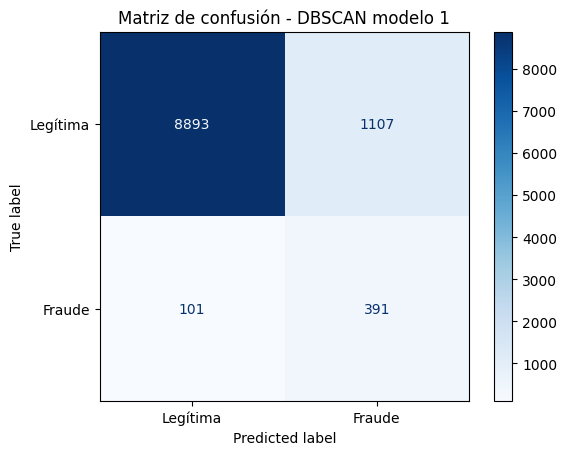

In [ ]:
y_true = df_dbscan["Class"]

# Predicción del modelo DBSCAN
y_pred = df_dbscan["pred_dbscan_1"]

# Creamos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizamos la matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legítima", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - DBSCAN modelo 1")
plt.grid(False)
plt.show()

## Métricas dbscan 1

Calculamos las métricas principales

In [ ]:
precision_dbscan_1 = precision_score(y_true, y_pred, zero_division=0)
recall_dbscan_1 = recall_score(y_true, y_pred, zero_division=0)
f1_dbscan_1 = f1_score(y_true, y_pred, zero_division=0)

print("Resultados DBSCAN Modelo 1")
print("Precision:", precision_dbscan_1)
print("Recall:", recall_dbscan_1)
print("F1-score:", f1_dbscan_1)

# Informe completo
print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

Resultados DBSCAN Modelo 1
Precision: 0.26101468624833113
Recall: 0.7947154471544715
F1-score: 0.392964824120603

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     10000
           1       0.26      0.79      0.39       492

    accuracy                           0.88     10492
   macro avg       0.62      0.84      0.66     10492
weighted avg       0.95      0.88      0.91     10492



## Modelo 2: dbscan con otros parámetros

Probamos un segundo modelo DBSCAN cambiando eps y min_samples. Esto permite comparar cómo cambian los resultados.

In [ ]:
modelo_dbscan_2 = DBSCAN(
    eps=4,
    min_samples=20,
    metric="euclidean"
)

# Aplicamos el modelo
labels_2 = modelo_dbscan_2.fit_predict(matriz_estandarizada)

# Creamos copia del DataFrame original
df_dbscan_2 = df.copy()

# Añadimos etiquetas del segundo modelo
df_dbscan_2["cluster_dbscan_2"] = labels_2

# Creamos predicción: -1 significa anomalía
df_dbscan_2["pred_dbscan_2"] = np.where(df_dbscan_2["cluster_dbscan_2"] == -1, 1, 0)

# Mostramos distribución de etiquetas
print("Etiquetas generadas por DBSCAN modelo 2:")
print(np.unique(labels_2, return_counts=True))

# Mostramos predicciones
print("\nPredicciones DBSCAN modelo 2:")
print(df_dbscan_2["pred_dbscan_2"].value_counts())

Etiquetas generadas por DBSCAN modelo 2:
(array([-1,  0,  1]), array([ 762,   73, 9657]))

Predicciones DBSCAN modelo 2:
pred_dbscan_2
0    9730
1     762
Name: count, dtype: int64


## Evaluación dbscan modelo 2

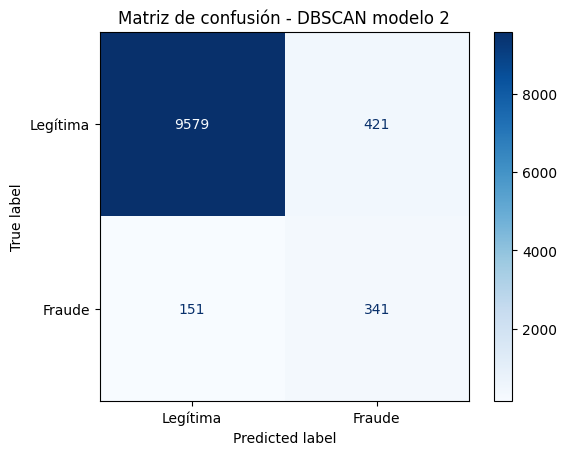

Resultados DBSCAN Modelo 2
Precision: 0.44750656167979
Recall: 0.693089430894309
F1-score: 0.543859649122807

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     10000
           1       0.45      0.69      0.54       492

    accuracy                           0.95     10492
   macro avg       0.72      0.83      0.76     10492
weighted avg       0.96      0.95      0.95     10492



In [ ]:
y_true_2 = df_dbscan_2["Class"]
y_pred_2 = df_dbscan_2["pred_dbscan_2"]

# Matriz de confusión
cm_2 = confusion_matrix(y_true_2, y_pred_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=["Legítima", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - DBSCAN modelo 2")
plt.grid(False)
plt.show()

# Métricas
precision_dbscan_2 = precision_score(y_true_2, y_pred_2, zero_division=0)
recall_dbscan_2 = recall_score(y_true_2, y_pred_2, zero_division=0)
f1_dbscan_2 = f1_score(y_true_2, y_pred_2, zero_division=0)

print("Resultados DBSCAN Modelo 2")
print("Precision:", precision_dbscan_2)
print("Recall:", recall_dbscan_2)
print("F1-score:", f1_dbscan_2)

print("\nClassification Report:")
print(classification_report(y_true_2, y_pred_2, zero_division=0))

## Modelo 1: isolation forest

Isolation Forest detecta anomalías aislando observaciones. Las observaciones que se aíslan más fácilmente se consideran más anómalas.

In [ ]:
iso_1 = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination=0.01,
    random_state=55
)

# Entrenamos el modelo con los datos estandarizados
iso_1.fit(matriz_estandarizada)

# Calculamos el score de anomalía.
# Multiplicamos por -1 para que valores más altos indiquen mayor anomalía.
score_anomalia_1 = -(iso_1.decision_function(matriz_estandarizada))

# Creamos copia del DataFrame original
df_iso = df.copy()

# Añadimos el score de anomalía
df_iso["score_iso_1"] = score_anomalia_1

# Mostramos las primeras filas
df_iso[["Class", "score_iso_1"]].head()

# El parámetro contamination en Isolation Forest se ha definido en base
# a la proporción esperada de fraude, permitiendo ajustar el número de
# anomalías detectadas.

,Class,score_iso_1
0,1,-0.227385
1,1,-0.192984
2,1,-0.204117
3,1,-0.095010
4,1,-0.139931


## Definir umbral de anomalía para isolation forest

Definimos un umbral por percentil. Por ejemplo, percentil 99 significa que el 1% con mayor score será clasificado como anomalía.

In [ ]:
N = 99

# El umbral de decisión se ha definido mediante percentiles del anomaly score,
# permitiendo adaptar la sensibilidad del modelo al nivel de riesgo deseado.
# Este enfoque es especialmente relevante en entornos financieros, donde
# el equilibrio entre falsos positivos y falsos negativos es crítico.



# Calculamos el umbral
umbral_1 = np.percentile(score_anomalia_1, N)

print("Umbral de anomalía:", umbral_1)

# Creamos una variable binaria:
# 1 = anomalía / posible fraude
# 0 = transacción legítima
df_iso["flag_anomalia_1"] = (df_iso["score_iso_1"] >= umbral_1).astype(int)

# Mostramos cuántas anomalías detecta
print(df_iso["flag_anomalia_1"].value_counts())

Umbral de anomalía: -3.019672456961581e-17
flag_anomalia_1
0    10387
1      105
Name: count, dtype: int64


## Matriz de confusión isolation forest 1

Variable real

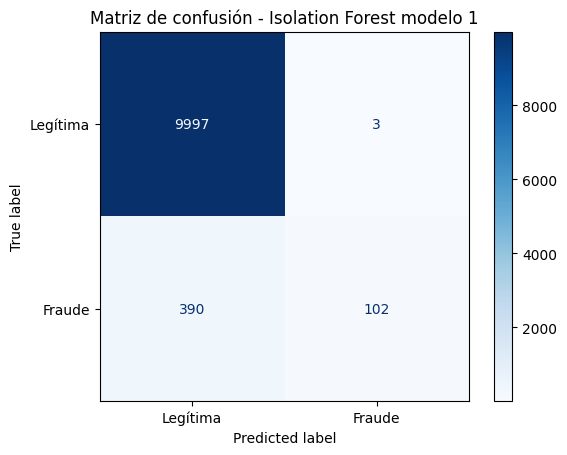

In [ ]:
y_true_iso = df_iso["Class"]

# Predicción del modelo
y_pred_iso = df_iso["flag_anomalia_1"]

# Matriz de confusión
cm_iso = confusion_matrix(y_true_iso, y_pred_iso)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_iso,
    display_labels=["Legítima", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Isolation Forest modelo 1")
plt.grid(False)
plt.show()

## Métricas isolation forest 1

In [ ]:
precision_iso_1 = precision_score(y_true_iso, y_pred_iso, zero_division=0)
recall_iso_1 = recall_score(y_true_iso, y_pred_iso, zero_division=0)
f1_iso_1 = f1_score(y_true_iso, y_pred_iso, zero_division=0)

print("Resultados Isolation Forest Modelo 1")
print("Precision:", precision_iso_1)
print("Recall:", recall_iso_1)
print("F1-score:", f1_iso_1)

print("\nClassification Report:")
print(classification_report(y_true_iso, y_pred_iso, zero_division=0))

Resultados Isolation Forest Modelo 1
Precision: 0.9714285714285714
Recall: 0.2073170731707317
F1-score: 0.3417085427135678

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     10000
           1       0.97      0.21      0.34       492

    accuracy                           0.96     10492
   macro avg       0.97      0.60      0.66     10492
weighted avg       0.96      0.96      0.95     10492



## Modelo 2: isolation forest con otros parámetros

Creamos un segundo modelo cambiando n_estimators, max_samples y contamination.

In [ ]:
iso_2 = IsolationForest(
    n_estimators=200,
    max_samples=0.8,
    contamination=0.02,
    random_state=55
)

# Entrenamos el modelo
iso_2.fit(matriz_estandarizada)

# Calculamos score de anomalía
score_anomalia_2 = -(iso_2.decision_function(matriz_estandarizada))

# Creamos copia del DataFrame
df_iso_2 = df.copy()

# Añadimos score
df_iso_2["score_iso_2"] = score_anomalia_2

# Definimos otro umbral.
# Percentil 98 implica que aproximadamente el 2% con mayor score
# será clasificado como anomalía.
N_2 = 98

umbral_2 = np.percentile(score_anomalia_2, N_2)

# Creamos variable de predicción
df_iso_2["flag_anomalia_2"] = (df_iso_2["score_iso_2"] >= umbral_2).astype(int)

print("Umbral modelo 2:", umbral_2)
print(df_iso_2["flag_anomalia_2"].value_counts())

Umbral modelo 2: 2.1914436411363258e-16
flag_anomalia_2
0    10282
1      210
Name: count, dtype: int64


## Evaluación isolation forest modelo 2

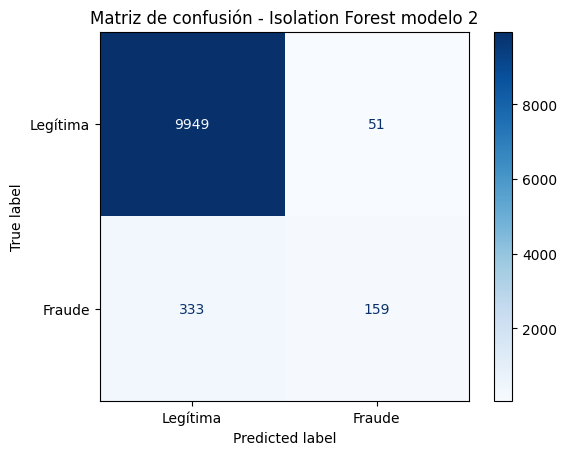

Resultados Isolation Forest Modelo 2
Precision: 0.7571428571428571
Recall: 0.3231707317073171
F1-score: 0.452991452991453

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10000
           1       0.76      0.32      0.45       492

    accuracy                           0.96     10492
   macro avg       0.86      0.66      0.72     10492
weighted avg       0.96      0.96      0.96     10492



In [ ]:
y_true_iso_2 = df_iso_2["Class"]
y_pred_iso_2 = df_iso_2["flag_anomalia_2"]

# Matriz de confusión
cm_iso_2 = confusion_matrix(y_true_iso_2, y_pred_iso_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_iso_2,
    display_labels=["Legítima", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Isolation Forest modelo 2")
plt.grid(False)
plt.show()

# Métricas
precision_iso_2 = precision_score(y_true_iso_2, y_pred_iso_2, zero_division=0)
recall_iso_2 = recall_score(y_true_iso_2, y_pred_iso_2, zero_division=0)
f1_iso_2 = f1_score(y_true_iso_2, y_pred_iso_2, zero_division=0)

print("Resultados Isolation Forest Modelo 2")
print("Precision:", precision_iso_2)
print("Recall:", recall_iso_2)
print("F1-score:", f1_iso_2)

print("\nClassification Report:")
print(classification_report(y_true_iso_2, y_pred_iso_2, zero_division=0))

## Comparación final de modelos

Creamos una tabla comparativa con los resultados obtenidos

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "DBSCAN Modelo 1",
        "DBSCAN Modelo 2",
        "Isolation Forest Modelo 1",
        "Isolation Forest Modelo 2"
    ],
    "Precision": [
        precision_dbscan_1,
        precision_dbscan_2,
        precision_iso_1,
        precision_iso_2
    ],
    "Recall": [
        recall_dbscan_1,
        recall_dbscan_2,
        recall_iso_1,
        recall_iso_2
    ],
    "F1-score": [
        f1_dbscan_1,
        f1_dbscan_2,
        f1_iso_1,
        f1_iso_2
    ]
})

# Mostramos la tabla comparativa
resultados

,Modelo,Precision,Recall,F1-score
0,DBSCAN Modelo 1,0.261015,0.794715,0.392965
1,DBSCAN Modelo 2,0.447507,0.693089,0.543860
2,Isolation Forest Modelo 1,0.971429,0.207317,0.341709
3,Isolation Forest Modelo 2,0.757143,0.323171,0.452991


## Analisis adicional

Este apartado profundiza en el comportamiento del modelo mediante el análisis del anomaly score y la proporción de fraude detectado. ------------------------------------------------------------ 1. DISTRIBUCIÓN DEL ANOMALY SCORE ------------------------------------------------------------

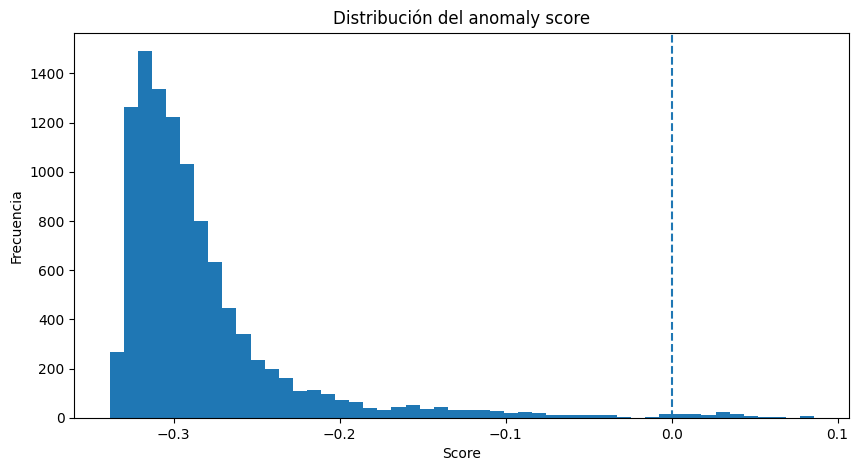

Anomalías detectadas: 105
Porcentaje: 1.0007624857033932
Fraudes reales: 492
Fraudes detectados: 102
Proporción capturada: 0.2073170731707317
Falsos positivos: 3
Predichos fraude: 105
Ratio falsos positivos: 0.02857142857142857


In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df_iso["score_iso_1"], bins=50)
plt.axvline(umbral_1, linestyle='--')
plt.title("Distribución del anomaly score")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

# ------------------------------------------------------------
# 2. NÚMERO DE ANOMALÍAS DETECTADAS
# ------------------------------------------------------------

anomalias = df_iso["flag_anomalia_1"].sum()
total = len(df_iso)

print("Anomalías detectadas:", anomalias)
print("Porcentaje:", anomalias / total * 100)

# ------------------------------------------------------------
# 3. FRAUDE CAPTURADO (RECALL REAL)
# ------------------------------------------------------------

fraudes_reales = df_iso["Class"].sum()
fraudes_detectados = ((df_iso["Class"] == 1) & (df_iso["flag_anomalia_1"] == 1)).sum()

print("Fraudes reales:", fraudes_reales)
print("Fraudes detectados:", fraudes_detectados)
print("Proporción capturada:", fraudes_detectados / fraudes_reales)

# Este análisis permite evaluar en profundidad la capacidad del modelo
# para identificar transacciones fraudulentas y su comportamiento en la
# detección de anomalías. La distribución del score muestra cómo se separan
# las observaciones normales de las anómalas, mientras que la proporción
# de fraude capturado refleja la efectividad real del modelo en términos
# de detección.

# ------------------------------------------------------------
# 4. FALSOS POSITIVOS
# ------------------------------------------------------------

# Falsos positivos
falsos_positivos = ((df_iso["Class"] == 0) & (df_iso["flag_anomalia_1"] == 1)).sum()

# Total predichos como fraude
predichos_fraude = df_iso["flag_anomalia_1"].sum()

print("Falsos positivos:", falsos_positivos)
print("Predichos fraude:", predichos_fraude)
print("Ratio falsos positivos:", falsos_positivos / predichos_fraude)

# El análisis de los falsos positivos revela que el modelo únicamente
# clasifica 3 transacciones legítimas como fraudulentas, sobre un total
# de 105 observaciones identificadas como anomalías. Esto se traduce en
# un ratio de falsos positivos extremadamente bajo (~2.86%).

# Este resultado es consistente con la elevada Precision observada en el
# modelo, indicando que la gran mayoría de las transacciones marcadas como
# fraude son efectivamente fraudulentas.

# Desde una perspectiva financiera, este comportamiento es altamente
# favorable en términos de eficiencia operativa, ya que minimiza los costes
# asociados a la revisión manual de transacciones legítimas. Un bajo número
# de falsos positivos reduce la fricción con el cliente y evita bloqueos
# innecesarios de operaciones, lo que mejora la experiencia del usuario.

# Sin embargo, este alto nivel de precisión viene acompañado de un coste
# significativo en términos de detección de fraude. Tal y como se ha
# observado previamente, el modelo presenta un Recall bajo (~20.7%),
# lo que implica que una gran proporción de fraudes no son detectados
# (falsos negativos).

# Este comportamiento refleja un enfoque extremadamente conservador,
# donde el modelo prioriza evitar errores de clasificación sobre la
# detección exhaustiva de anomalías. En términos de gestión del riesgo,
# esto puede resultar problemático, ya que los falsos negativos implican
# pérdidas económicas directas para la entidad financiera.

# En consecuencia, el modelo muestra un claro desequilibrio en el trade-off
# entre Precision y Recall, favoreciendo la reducción de falsos positivos
# a costa de una menor capacidad de detección.

# Desde un punto de vista estratégico, este resultado sugiere la necesidad
# de recalibrar el umbral de decisión o ajustar los hiperparámetros del
# modelo, con el objetivo de incrementar la sensibilidad (Recall) y mejorar
# la cobertura del fraude, incluso si ello implica asumir un mayor número
# de falsos positivos.

# En definitiva, aunque el modelo presenta un rendimiento excelente en
# términos de precisión, su aplicabilidad en un entorno real de detección
# de fraude requiere un mayor equilibrio entre eficiencia operativa y
# capacidad de detección, alineando el modelo con el apetito de riesgo de
# la entidad financiera.

# Este comportamiento es característico de modelos conservadores en
# detección de fraude, donde se prioriza la precisión sobre la cobertura,
# siendo necesario ajustar el modelo en función del coste relativo de los
# errores en el contexto operativo.

## Interpretación del análisis adicional

La distribución del anomaly score muestra una clara concentración de observaciones en valores negativos bajos (aproximadamente entre -0.35 y -0.20), lo que indica que la mayoría de las transacciones presentan un comportamiento homogéneo y son consideradas normales por el modelo. La presencia de una cola hacia valores más altos (cercanos a 0) refleja la existencia de observaciones atípicas. El umbral definido (línea discontinua) permite aislar aproximadamente el 1% de las observaciones con mayor grado de anomalía, identificándolas como potencialmente fraudulentas. En términos cuantitativos, el modelo detecta 105 anomalías, lo que representa aproximadamente el 1% del total de transacciones. Esta proporción es coherente con la baja frecuencia del fraude en entornos financieros reales, lo que sugiere una adecuada calibración inicial del modelo. Sin embargo, al analizar la capacidad real de detección, se observa que de un total de 492 fraudes reales, el modelo únicamente identifica 102, lo que se traduce en un Recall aproximado del 20.7%. Este resultado indica que el modelo presenta una baja sensibilidad, dejando sin detectar una proporción significativa de transacciones fraudulentas (falsos negativos). Desde una perspectiva financiera, este comportamiento supone un riesgo elevado, ya que los fraudes no detectados implican pérdidas económicas directas para la entidad, además de posibles impactos reputacionales y regulatorios. Por otro lado, el reducido número de anomalías detectadas sugiere que el modelo es altamente conservador, priorizando la reducción de falsos positivos. Esto implica menores costes operativos asociados a la revisión manual, pero a costa de una menor efectividad en la detección de fraude. Este resultado pone de manifiesto la importancia crítica del umbral de decisión. Un umbral basado en el percentil 99 restringe la detección a los casos más extremos, limitando la capacidad del modelo para capturar fraudes menos evidentes. En consecuencia, sería recomendable explorar umbrales menos restrictivos (por ejemplo, percentiles 97 o 98), con el objetivo de incrementar el Recall y mejorar la cobertura del fraude, asumiendo un mayor número de falsos positivos. En conclusión, el modelo Isolation Forest, en su configuración actual, presenta un enfoque conservador adecuado para entornos donde se prioriza la eficiencia operativa. No obstante, para aplicaciones reales de detección de fraude, sería necesario ajustar el umbral y/o los hiperparámetros con el fin de mejorar la sensibilidad del modelo y reducir el riesgo de pérdidas derivadas de fraudes no detectados. Recomendación: ajustar umbral para mejorar Recall

## Gráfico comparativo de resultados

Representamos gráficamente las métricas para comparar modelos

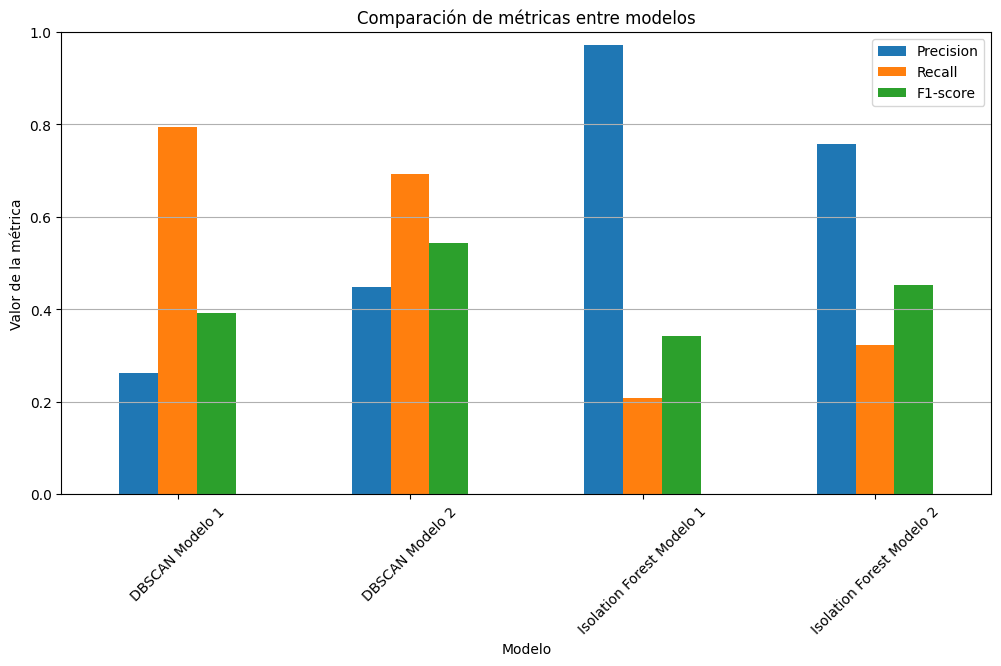

In [ ]:
resultados.set_index("Modelo")[["Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## Conclusión final

El presente análisis ha abordado la detección de fraude financiero mediante la aplicación de técnicas de aprendizaje no supervisado, concretamente DBSCAN e Isolation Forest, sobre un dataset caracterizado por una elevada dimensionalidad y un fuerte desbalanceo de clases. Desde el punto de vista metodológico, el preprocesamiento de los datos, incluyendo la estandarización de las variables, ha sido un paso crítico, especialmente para DBSCAN, cuyo funcionamiento depende directamente de métricas de distancia. Este proceso ha permitido garantizar la coherencia en la estructura de los datos y evitar sesgos derivados de escalas heterogéneas. En relación con los resultados obtenidos, DBSCAN ha mostrado una elevada capacidad de detección de fraude (alto Recall), especialmente en su primera configuración (~0.79), lo que indica que el modelo es capaz de identificar una gran proporción de transacciones fraudulentas. Sin embargo, esta elevada sensibilidad viene acompañada de una baja Precision (~0.26), lo que implica un elevado número de falsos positivos y, por tanto, un incremento significativo en los costes operativos asociados a la revisión de transacciones legítimas. La segunda configuración de DBSCAN mejora el equilibrio entre métricas, alcanzando una Precision superior (~0.45) y un F1-score más elevado (~0.54), lo que sugiere un mejor compromiso entre detección de fraude y control del ruido. Este modelo se posiciona como la mejor alternativa en términos globales dentro de los métodos evaluados. Por su parte, Isolation Forest ha mostrado un comportamiento significativamente diferente, adoptando un enfoque más conservador. En su primera configuración, alcanza una Precision muy elevada (~0.97), lo que implica que prácticamente todas las transacciones identificadas como fraude son efectivamente fraudulentas. No obstante, su Recall es muy bajo (~0.20), detectando únicamente una pequeña proporción del fraude total. El análisis adicional del anomaly score confirma este comportamiento, ya que el modelo, con un umbral basado en el percentil 99, identifica únicamente el 1% de las observaciones como anómalas. En términos absolutos, esto se traduce en 105 anomalías detectadas frente a un total de 492 fraudes reales, capturando aproximadamente el 20.7% del fraude existente. Desde una perspectiva financiera, este resultado implica un riesgo significativo, ya que los falsos negativos (fraudes no detectados) representan pérdidas económicas directas, además de posibles implicaciones reputacionales y regulatorias. Por otro lado, el bajo número de falsos positivos reduce los costes operativos, reflejando un modelo orientado a la eficiencia más que a la cobertura del fraude. La segunda configuración de Isolation Forest mejora ligeramente el Recall (~0.32), incrementando la detección de fraude, aunque a costa de una reducción en Precision. Este comportamiento pone de manifiesto la importancia del ajuste del umbral de decisión, que actúa como un mecanismo clave en la gestión del trade-off entre falsos positivos y falsos negativos. En términos comparativos, DBSCAN se caracteriza por un enfoque más agresivo en la detección de fraude, maximizando el Recall, mientras que Isolation Forest adopta una estrategia más conservadora, priorizando la Precision. Esta diferencia refleja dos aproximaciones distintas a la gestión del riesgo financiero. Desde una perspectiva operativa, la elección del modelo óptimo debe alinearse con el apetito de riesgo de la entidad. En entornos donde el coste de no detectar fraude es elevado, se recomienda priorizar modelos con alto Recall, como DBSCAN, incluso a costa de incrementar los falsos positivos. Por el contrario, en contextos donde la eficiencia operativa y la reducción de costes de revisión son prioritarias, modelos como Isolation Forest pueden resultar más adecuados. No obstante, los resultados sugieren que ninguna de las técnicas, de forma aislada, ofrece un rendimiento óptimo. Por ello, una estrategia recomendada en entornos reales sería la combinación de ambos enfoques en un sistema híbrido, donde Isolation Forest actúe como filtro inicial de alta precisión y DBSCAN como mecanismo complementario para maximizar la detección de anomalías. En conclusión, la detección de fraude mediante técnicas de machine learning no supervisado constituye una herramienta estratégica para las entidades financieras, pero requiere una adecuada calibración de modelos y una interpretación crítica de los resultados para su correcta aplicación en entornos reales.